# 特征工程和多项式回归

这一节用一个简单的二次函数例子说明：线性回归本身只能拟合直线，但通过构造新特征，也可以拟合弯曲的关系。

## 1. 为什么需要特征工程

普通线性回归的形式是：

$$
f_{\vec{w},b}(\vec{x})=w_1x_1+w_2x_2+\cdots+w_nx_n+b
$$

如果数据本身是弯曲的，仅靠调整 $w$ 和 $b$ 很难拟合好。特征工程的思路是：不改变线性回归算法，而是给模型提供更合适的新特征。

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def zscore_normalize_features(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_scaled = (X - mu) / sigma
    return X_scaled, mu, sigma


def compute_cost(X, y, w, b):
    m = len(y)
    error = X @ w + b - y
    return np.sum(error ** 2) / (2 * m)


def gradient_descent(X, y, alpha, num_iters):
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0
    cost_history = []

    for _ in range(num_iters):
        error = X @ w + b - y
        dj_dw = X.T @ error / m
        dj_db = np.sum(error) / m

        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost_history.append(compute_cost(X, y, w, b))

    return w, b, cost_history

## 2. 不做特征工程：直线拟合曲线

先构造一个简单数据集：

$$
y = 1 + x^2
$$

如果只把 $x$ 作为特征，模型只能学习 $f(x)=wx+b$，也就是一条直线。

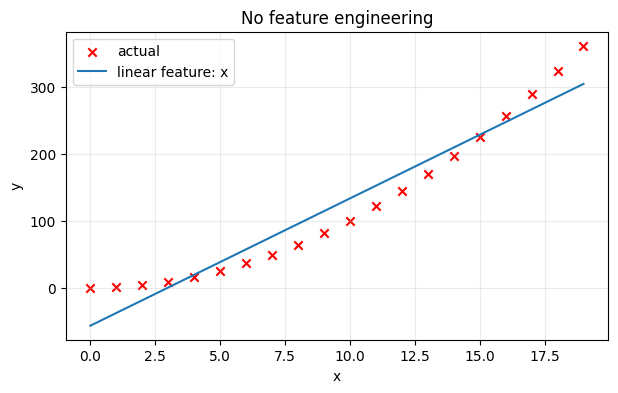

最终代价: 438.90


In [2]:
x = np.arange(0, 20, 1)
y = 1 + x ** 2

X_linear = x.reshape(-1, 1)
X_linear_scaled, linear_mu, linear_sigma = zscore_normalize_features(X_linear)

w_linear, b_linear, cost_linear = gradient_descent(X_linear_scaled, y, alpha=0.1, num_iters=1000)
prediction_linear = X_linear_scaled @ w_linear + b_linear

plt.figure(figsize=(7, 4))
plt.scatter(x, y, marker="x", c="r", label="actual")
plt.plot(x, prediction_linear, label="linear feature: x")
plt.xlabel("x")
plt.ylabel("y")
plt.title("No feature engineering")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print(f"最终代价: {cost_linear[-1]:.2f}")

## 3. 加入多项式特征

如果我们把输入特征从 $x$ 改成 $x^2$，线性回归就可以学习：

$$
f(x)=w_1x^2+b
$$

算法仍然是线性回归，变化的是输入给模型的特征。

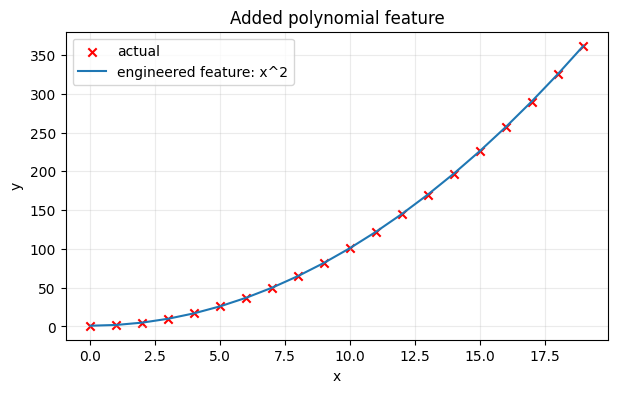

最终代价: 0.000000


In [3]:
X_poly = (x ** 2).reshape(-1, 1)
X_poly_scaled, poly_mu, poly_sigma = zscore_normalize_features(X_poly)

w_poly, b_poly, cost_poly = gradient_descent(X_poly_scaled, y, alpha=0.1, num_iters=1000)
prediction_poly = X_poly_scaled @ w_poly + b_poly

plt.figure(figsize=(7, 4))
plt.scatter(x, y, marker="x", c="r", label="actual")
plt.plot(x, prediction_poly, label="engineered feature: x^2")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Added polynomial feature")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print(f"最终代价: {cost_poly[-1]:.6f}")

## 4. 让模型从多个候选特征中选择

实际问题中，我们不一定提前知道哪个特征最有用。可以先把 $x$、$x^2$、$x^3$ 都画出来，看哪个特征和目标 $y$ 更接近线性关系。

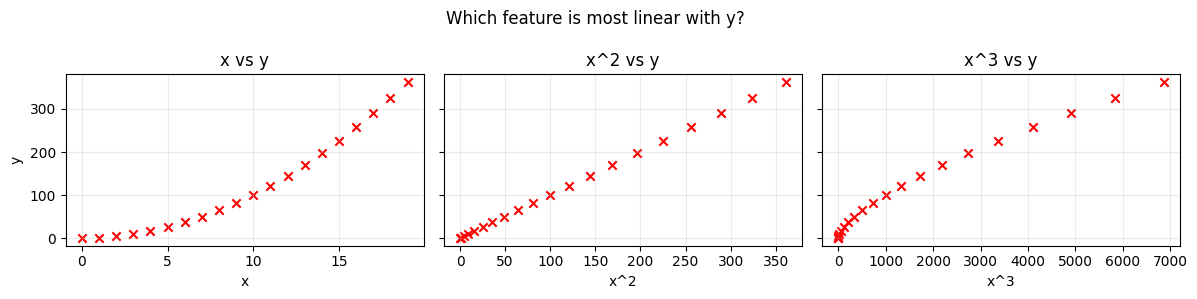

训练后的权重：
x   : 25.20
x^2 : 49.30
x^3 : 40.35
最终代价: 4.216325


In [4]:
X_candidates = np.column_stack([x, x ** 2, x ** 3])
X_candidates_scaled, candidate_mu, candidate_sigma = zscore_normalize_features(X_candidates)

feature_labels = ["x", "x^2", "x^3"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

for i, ax in enumerate(axes):
    ax.scatter(X_candidates[:, i], y, marker="x", c="r")
    ax.set_xlabel(feature_labels[i])
    ax.set_title(f"{feature_labels[i]} vs y")
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("y")
fig.suptitle("Which feature is most linear with y?")
plt.tight_layout()
plt.show()

w_candidates, b_candidates, cost_candidates = gradient_descent(
    X_candidates_scaled, y, alpha=0.1, num_iters=1000
)

print("训练后的权重：")
print(f"x   : {w_candidates[0]:.2f}")
print(f"x^2 : {w_candidates[1]:.2f}")
print(f"x^3 : {w_candidates[2]:.2f}")
print(f"最终代价: {cost_candidates[-1]:.6f}")

## 5. 多项式特征也需要缩放

多项式特征的量级差异通常很大。例如 $x$、$x^2$、$x^3$ 的范围会快速变大，所以训练前通常要做特征缩放。

In [5]:
print(f"缩放前每列范围: {np.ptp(X_candidates, axis=0)}")
print(f"缩放后每列范围: {np.ptp(X_candidates_scaled, axis=0)}")

缩放前每列范围: [  19  361 6859]
缩放后每列范围: [3.29501788 3.18076489 3.28307153]


## 6. 复函数

特征工程也可以拟合更复杂的函数。下面用多阶多项式特征拟合：

$$
y = \cos(\frac{x}{2})
$$

这里的目标不是解释每个多项式项，而是说明：只要构造了足够有表达力的特征，线性回归也可以拟合非线性形状。

In [ ]:
x_complex = np.arange(0, 20, 1)
y_complex = np.cos(x_complex / 2)

X_complex = np.c_[
    x_complex,
    x_complex**2,
    x_complex**3,
    x_complex**4,
    x_complex**5,
    x_complex**6,
    x_complex**7,
    x_complex**8,
    x_complex**9,
    x_complex**10,
    x_complex**11,
    x_complex**12,
    x_complex**13,
]
X_complex_scaled, complex_mu, complex_sigma = zscore_normalize_features(X_complex)

X_complex_with_bias = np.c_[X_complex_scaled, np.ones(X_complex_scaled.shape[0])]
params_complex = np.linalg.lstsq(X_complex_with_bias, y_complex, rcond=None)[0]
w_complex = params_complex[:-1]
b_complex = params_complex[-1]

prediction_complex = X_complex_scaled @ w_complex + b_complex
cost_complex = compute_cost(X_complex_scaled, y_complex, w_complex, b_complex)

plt.figure(figsize=(8, 4))
plt.scatter(x_complex, y_complex, marker="x", c="r", label="Actual Value")
plt.plot(x_complex, prediction_complex, label="Predicted Value")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Normalized x, x^2, ..., x^13 features")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print(f"最终代价: {cost_complex:.6f}")

## 7. 小结

| 概念 | 作用 |
| --- | --- |
| 特征工程 | 根据已有特征构造更有表达力的新特征 |
| 多项式回归 | 把 $x^2$、$x^3$ 等多项式项作为新特征 |
| 特征缩放 | 防止新特征数值过大，让梯度下降更稳定 |

多项式回归没有改变线性回归的训练方式，它改变的是输入给模型的特征。